# Toy model for correlated $T_1$ with amplitude-modulated noise

In a $T_1$ relaxometry experiment, a qubit depolarizes due to noise,

\begin{equation}
S_z(t) = \vert c_1(t) \vert^2 = e^{-\Gamma t}
\end{equation}

where the decay rate is determined by the noise power spectral density at the resonant frequency $\omega_{01}$ as described by Fermi's golden rule,

\begin{equation}
\Gamma = \gamma^2 S_{V_{01}} (\omega_{01}) \vert \langle \psi_1 \vert \sigma_V \vert \psi_0 \rangle \vert^2
\end{equation}

following the notation in Degen, C. L., F. Reinhard, and P. Cappellaro, 2017, Rev. Mod. Phys. 89, 035002.


Consider an experiment in which two qubits $(n = 1,2)$ are driven by noise whose amplitude is modulated by a shared Gaussian source. Assume for simplicity that the strength of the noise is constant within an individual run of the experiment $i$ but varies between run (a quasi-static approximation for the amplitude modulation). Then the decay rate for qubit $n$ in experiment run $i$ is given by $\Gamma_{n, i} = A_i P_n$, where $A_i$ is the Gaussian random variable describing the amplitude modulation and $P_n$ is the fixed power spectral density of the carrier noise at the resonant frequency of qubit $n$ and also absorbs any other constants appearing in Fermi's golden rule.

We are interested in the averages of $S_1$ and $S_2$ over many runs of the experiment, and in particular in any correlations that build up between them due to the amplitude-modulated noise. To start, let's evaluate

\begin{equation}
\langle S_n(t) \rangle = \langle e^{-\Gamma_{n, i} t} \rangle_i = \langle e^{-A_i P_n t} \rangle_i
\end{equation}

where $\langle \rangle_i$ denotes an average taken over experimental runs $i$. This is easy to evaluate: since $A_i P_n t$ is a Gaussian random variable, $\langle e^{-A_i P_n t} \rangle_i$ is just its moment-generating function, which can be found in a table. For $Z \sim \mathcal{N}(\mu, \sigma^2)$, one has $\mathbb{E} \left[ e^{tZ} \right] = e^{\mu t + \sigma^2 t^2 /2 }$. Denoting the variance of $A_i P_n$ by $p_n^2 \langle \delta A \rangle^2$ and the mean by $p_n \bar{A}$, we get

\begin{equation}
\langle S_n(t) \rangle = e^{p_n \bar{A} t} e^{-p_n^2 \langle \delta A \rangle^2 t^2 / 2}
\end{equation}


It follows, then, that

\begin{equation}
\langle S_1(t) \rangle \langle S_2(t) \rangle = e^{(p_1 + p_2) \bar{A} t} e^{-(p_1^2 + p_2^2) \langle \delta A \rangle^2 t^2 / 2}
\end{equation}

In order to understand whether any correlations build up between the two qubits due to the depolarizing noise, we next evaluate

\begin{equation}
\langle S_1(t) S_2(t) \rangle = \langle e^{-A_i P_1 t} e^{-A_i P_2 t} \rangle_i = \langle e^{-A_i (P_1 + P_2) t} \rangle_i
\end{equation}

Since $A_i (P_1 + P_2) t$ is just another Gaussian random variable, this expectation can be evaluated using the  same method as before, giving

\begin{align}
\langle S_1(t) S_2(t) \rangle &= e^{(p_1 + p_2) \bar{A} t} e^{-(p_1 + p_2)^2 \langle \delta A \rangle^2 t^2 / 2} \\
&\neq \langle S_1(t) \rangle \langle S_2(t) \rangle
\end{align}

Note that $\langle S_1(t) \rangle \langle S_2(t) \rangle$ deviates from $\langle S_1(t) S_2(t) \rangle$ in that $(p_1^2 + p_2^2)$ appears in the Gaussian term of the former while $(p_1 + p_2)^2$ appears in the Gaussian term of the latter. Taking their difference, we therefore get a correlation that depends on the cross-term $2 p_1 p_2 \langle \delta A \rangle^2$,

\begin{equation}
\langle S_1(t) S_2(t) \rangle - \langle S_1(t) \rangle \langle S_2(t) \rangle = e^{-(p_1 + p_2) \bar{A} t} e^{(p_1^2 + p_2^2) \langle \delta A \rangle^2 t^2 /2} \left[ e^{-2 p_1 p_2 \langle \delta A \rangle^2 t^2 / 2} - 1 \right]
\end{equation}


The bracketed term begins at $0$ at early times as $e^0 - 1 = 0$, then grows to $-1$ at late times. The term outside the brackets begins at $1$ at early times and shrinks to $0$ at late times. Combined, they produce what appears to be a "burst" in the correlation at intermediate times. Intuitively, the correlation appears as a "burst" because the depolarization in response to the noise takes time to build up (at $t = 0$, the qubits are in the same state, so $\langle S_1(0) S_2(0) \rangle$ is necessarily the same as $\langle S_1(0) \rangle \langle S_2(0) \rangle$). Of course, as the two qubits eventually depolarize completely, they return to an uncorrelated state. It also makes sense that the growth of the correlation depends on the variance of the shared noise $\langle \delta A \rangle^2$, as this is what "co-varies" between trials of the experiment and causes a deviation of $\langle S_1(t) S_2(t) \rangle$ from the independent qubit decays $\langle S_1(t) \rangle \langle S_2(t) \rangle$.

## Results

This is plotted below for several values of $\langle \delta A \rangle^2$ with $\bar{A}$ set to 1 and $p_1 = p_2$ set to produce a $T_1$ of about 2 microseconds.

Note that $\langle S_1 S_2 \rangle - \langle S_1 \rangle \langle S_2 \rangle$ is clearly negative in the above expression, whereas it's positive in Hoang's data. I added an ad-hoc - sign to correct for this in the plots. Could the just be a difference in how $S_{1, 2}$ are defined here vs. in the experiment, or is it a more fundamental issue with the model?

In [39]:
import numpy as np
import matplotlib.pyplot as plt

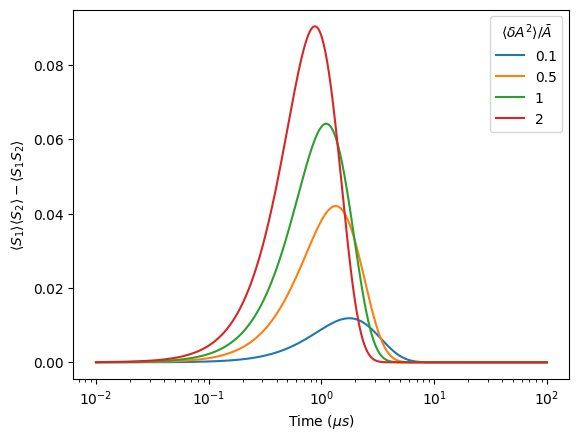

In [52]:
p1 = 5e5 # Set to produce "bare" T1 time of about 2 us
p2 = 5e5
dA2 = [0.1, 0.5, 1, 2]

t = np.logspace(-8, -4, 500)
corr = np.zeros([len(t), len(dA2)])
for i in range(len(dA2)):
    corr[:, i] = -np.exp(-(p1 + p2) * t) * np.exp(-(p1**2 + p2**2) * dA2[i] * t**2 / 2) * (np.exp(-2*p1*p2 * dA2[i] * t**2 /2) - 1)

plt.semilogx(t * 1e6, corr)
plt.xlabel('Time ($\mu s$)')
plt.ylabel(r'$\langle S_1 \rangle \langle S_2 \rangle - \langle S_1 S_2 \rangle$')
plt.legend(dA2, title=r'$\langle \delta A^2 \rangle / \bar{A}$')
plt.show()

## Corrected version

There was a slight shortcoming in the previous derivation. The Gaussian amplitude modulation should probably be squared as it enters Fermi's golden rule through the power spectral density. Now modeling the amplitude modulation as a Gaussian variable $A \sim \mathcal{N}(0, \sigma^2)$ and the decay rate as $\Gamma_{n, i} = A_i^2 P_n$, we get

\begin{equation}
\langle S_n (t) \rangle = \langle e^{-A^2 p_n t} \rangle = \frac{1}{\sqrt{1 + 2 p_n \langle \delta A^2 \rangle t}}
\end{equation}

where the expectation can again be found in a moment-generating function table. 

Working through the correlation in a very similar manner, eventually we get

\begin{equation}
\langle S_1(t) S_2(t) \rangle - \langle S_1(t) \rangle \langle S_2(t) \rangle = \frac{1}{\sqrt{1 + 2 (p_1 + p_2) \langle \delta A^2 \rangle t}} - \frac{1}{\sqrt{1 + 2 (p_1 + p_2) \langle \delta A^2 \rangle t + 4 p_1 p_2 \langle \delta A^2 \rangle^2 t^2}}
\end{equation}

Note that the correlation has the correct sign now, in the sense that it becomes positive when the spins are initialized in the same state.

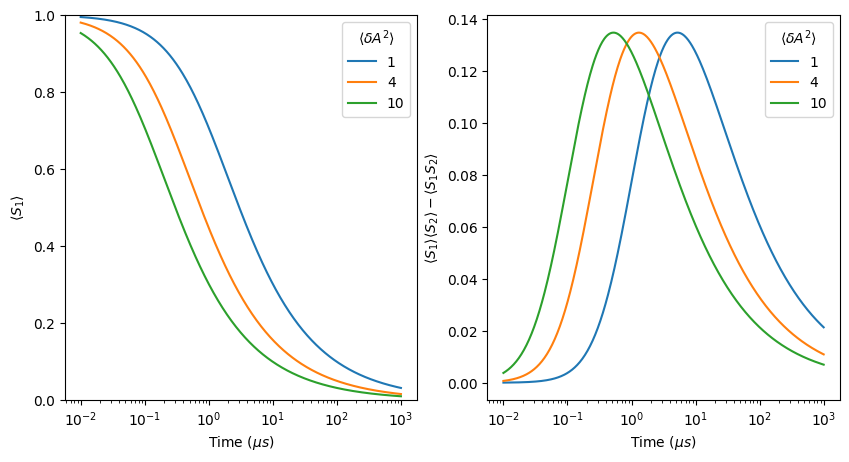

In [69]:
p1 = 5e5 # Set to produce "bare" T1 time of about 2 us
p2 = 5e5
dA2 = [1, 4, 10]

t = np.logspace(-8, -3, 500)
corr = np.zeros([len(t), len(dA2)])
decay = np.zeros_like(corr)
for i in range(len(dA2)):
    corr[:, i] = 1/np.sqrt(1 + 2*(p1 + p2) * dA2[i] * t) - 1/np.sqrt(1 + 2*(p1 + p2) * dA2[i] * t + 4*p1*p2 * dA2[i]**2 * t**2)
    decay[:, i] = 1/np.sqrt(1 + 2*p1 * dA2[i] * t)
    
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].semilogx(t * 1e6, decay)
axes[0].set_xlabel('Time ($\mu s$)')
axes[0].set_ylabel(r'$\langle S_1 \rangle$')
axes[0].set_ylim(0, 1)
axes[0].legend(dA2, title=r'$\langle \delta A^2 \rangle$')

axes[1].semilogx(t * 1e6, corr)
axes[1].set_xlabel('Time ($\mu s$)')
axes[1].set_ylabel(r'$\langle S_1 \rangle \langle S_2 \rangle - \langle S_1 S_2 \rangle$')
axes[1].legend(dA2, title=r'$\langle \delta A^2 \rangle$')

plt.show()